Import the Dependencies

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans 

Data Collection And Analysis 

In [4]:
#loading the data from csv file to a pandas DataFrame

customer_data = pd.read_csv('context/Mall_Customers.csv')

In [5]:
#first 5 rows of the data
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


coluna (spending score) = quanto mais proximo de 1, menos a pessoa gasta no shopping, quanto mais proximo de 100 mais a pessoa gasta no shopping 

In [6]:
# finding the numbers of rows and columns in the data 
customer_data.shape 

(200, 5)

In [7]:
# getting some informations about the data 
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
#checking for missing values in the data 
customer_data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

que colunas vamos precisar para o clustering

escolher as colunas Annual Income e Spending Score para o clustering

In [ ]:

X = customer_data.iloc[:, [3, 4]].values
#iloc = seleção por posição, : = todas as linhas, [3, 4] = colunas 3 e 4
# virou um array numpy, pois o KMeans do sklearn trabalha com arrays numpy
#slicing the dataset to obtain the annual income and spending score columns
print(X)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

Choosing the number of clusters 

WCSS -> Within-Cluster-Sum-of-Squares


In [ ]:
# finding wscc value for different number of clusters
#encontrar o numero ideal de cluster usando o método do cotovelo
wscc = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wscc.append(kmeans.inertia_)

    #.inertia_ retorna o WCSS calculado pelo modelo
    #Adiciona esse valor à lista


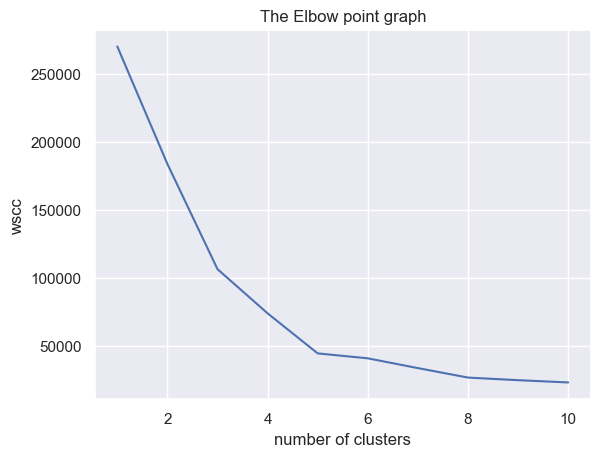

In [17]:
#plot the elbow graph to find the optimal number of clusters

sns.set()
plt.plot(range(1, 11), wscc)
plt.title('The Elbow point graph')
plt.xlabel('number of clusters')
plt.ylabel('wscc')
plt.show()


Optimum number of clusters = 5

training the k-means clustering modelo

O que é WCSS?

WCSS = Within-Cluster Sum of Squares (Soma dos Quadrados Dentro do Cluster)

Mede o quão "compactos" são os clusters — a soma das distâncias ao quadrado de cada ponto até o centroide do seu cluster. Quanto menor o WCSS, mais agrupados estão os pontos.

In [18]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)

#return a label for each data point based on their cluster
Y = kmeans.fit_predict(X)

print(Y)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


Y = kmeans.fit_predict(X)

Esse método faz duas coisas em uma só linha:

.fit → treina o modelo, encontra os 5 centroides nos dados

.predict → classifica cada cliente em um dos 5 clusters

O resultado Y é um array com um número (0 a 4) para cada cliente, indicando a qual cluster ele pertence:


[4 3 4 3 4 3 4 3 4 ... ]
 ^           ^
cliente 1    cliente 4
no cluster 4  no cluster 3

5 clusters = 0, 1, 2, 3, 4

visualizing all the clusters 

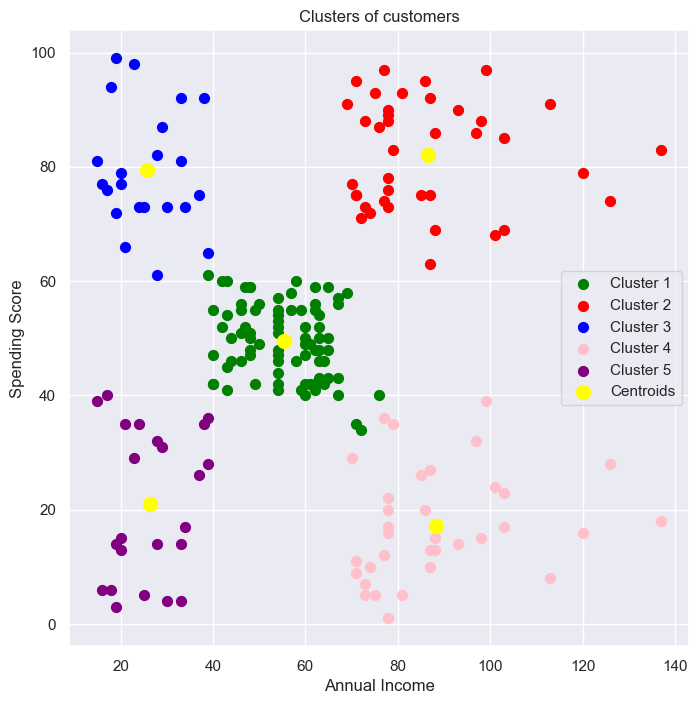

In [21]:
#ploting all the clusters and their centroids 

plt.figure(figsize=(8, 8))
plt.scatter(X[Y ==0, 0], X[Y == 0, 1], s = 50, c = 'green', label = 'Cluster 1')
plt.scatter(X[Y ==1, 0], X[Y == 1, 1], s = 50, c = 'red', label = 'Cluster 2')
plt.scatter(X[Y ==2, 0], X[Y == 2, 1], s = 50, c = 'blue', label = 'Cluster 3')
plt.scatter(X[Y ==3, 0], X[Y == 3, 1], s = 50, c = 'pink', label = 'Cluster 4')
plt.scatter(X[Y ==4, 0], X[Y == 4, 1], s = 50, c = 'purple', label = 'Cluster 5')


#plot the centroids 

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()